# Clasificador de imágenes con CIFAR-100

Notebook para clasificar tres clases: `apple`, `orange` y `pear`.

## 1. Librerías

In [1]:
import os
import tarfile
import pickle
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


## 2. Descargar CIFAR-100

In [2]:
url_cifar100 = "https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz"
archivo_tgz = "cifar-100-python.tar.gz"
carpeta_cifar = "cifar-100-python"

if not os.path.exists(archivo_tgz):
    print("Descargando CIFAR-100...")
    urllib.request.urlretrieve(url_cifar100, archivo_tgz)
    print("Descarga completada.")
else:
    print("El archivo ya existe.")

if not os.path.exists(carpeta_cifar):
    print("Extrayendo dataset...")
    with tarfile.open(archivo_tgz, "r:gz") as tar:
        tar.extractall()
    print("Extracción completada.")
else:
    print("El dataset ya está extraído.")


Descargando CIFAR-100...
Descarga completada.
Extrayendo dataset...
Extracción completada.


## 3. Cargar datos

In [3]:
def cargar_pickle(ruta):
    with open(ruta, "rb") as archivo:
        return pickle.load(archivo, encoding="latin1")


train_data = cargar_pickle(os.path.join(carpeta_cifar, "train"))
test_data = cargar_pickle(os.path.join(carpeta_cifar, "test"))
meta_data = cargar_pickle(os.path.join(carpeta_cifar, "meta"))

x_train = train_data["data"]
y_train = np.array(train_data["fine_labels"])
x_test = test_data["data"]
y_test = np.array(test_data["fine_labels"])
fine_labels = meta_data["fine_label_names"]

print("Entrenamiento:", x_train.shape)
print("Prueba:", x_test.shape)
print("Cantidad de clases:", len(fine_labels))


Entrenamiento: (50000, 3072)
Prueba: (10000, 3072)
Cantidad de clases: 100


## 4. Seleccionar clases

In [4]:
clases_seleccionadas = ["apple", "orange", "pear"]
indices_clases = [fine_labels.index(clase) for clase in clases_seleccionadas]

print("Clases seleccionadas:", clases_seleccionadas)
print("Índices:", indices_clases)


Clases seleccionadas: ['apple', 'orange', 'pear']
Índices: [0, 53, 57]


## 5. Filtrar dataset

In [5]:
def filtrar_clases(x, y, indices):
    mascara = np.isin(y, indices)
    x_filtrado = x[mascara]
    y_filtrado = y[mascara]
    y_nuevo = np.zeros_like(y_filtrado)

    for nueva_etiqueta, etiqueta_original in enumerate(indices):
        y_nuevo[y_filtrado == etiqueta_original] = nueva_etiqueta

    return x_filtrado, y_nuevo


x_train_filtrado, y_train_filtrado = filtrar_clases(x_train, y_train, indices_clases)
x_test_filtrado, y_test_filtrado = filtrar_clases(x_test, y_test, indices_clases)

print("Imágenes de entrenamiento:", x_train_filtrado.shape)
print("Etiquetas de entrenamiento:", y_train_filtrado.shape)
print("Imágenes de prueba:", x_test_filtrado.shape)
print("Etiquetas de prueba:", y_test_filtrado.shape)


Imágenes de entrenamiento: (1500, 3072)
Etiquetas de entrenamiento: (1500,)
Imágenes de prueba: (300, 3072)
Etiquetas de prueba: (300,)


## 6. Función para reconstruir imágenes

In [6]:
def convertir_a_imagen(imagen_aplanada):
    r = imagen_aplanada[0:1024].reshape(32, 32)
    g = imagen_aplanada[1024:2048].reshape(32, 32)
    b = imagen_aplanada[2048:3072].reshape(32, 32)
    return np.stack([r, g, b], axis=2)


## 7. Mostrar ejemplos del dataset

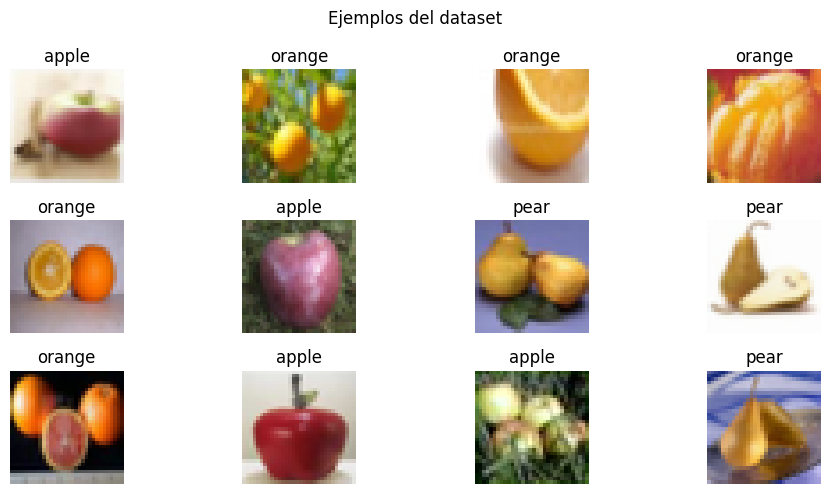

In [7]:
plt.figure(figsize=(10, 5))

for i in range(12):
    imagen = convertir_a_imagen(x_train_filtrado[i])
    plt.subplot(3, 4, i + 1)
    plt.imshow(imagen)
    plt.title(clases_seleccionadas[y_train_filtrado[i]])
    plt.axis("off")

plt.suptitle("Ejemplos del dataset")
plt.tight_layout()
plt.show()


## 8. Normalizar imágenes

In [8]:
x_train_normalizado = x_train_filtrado.astype("float32") / 255.0
x_test_normalizado = x_test_filtrado.astype("float32") / 255.0

print("Mínimo:", x_train_normalizado.min())
print("Máximo:", x_train_normalizado.max())


Mínimo: 0.0
Máximo: 1.0


## 9. Crear modelo

In [9]:
modelo = Pipeline([
    ("escalador", StandardScaler()),
    ("clasificador", LogisticRegression(max_iter=1000, random_state=42))
])

modelo


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('escalador', ...), ('clasificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, 

## 10. Entrenar modelo

In [10]:
print("Entrenando modelo...")
modelo.fit(x_train_normalizado, y_train_filtrado)
print("Entrenamiento terminado.")


Entrenando modelo...
Entrenamiento terminado.


## 11. Realizar predicciones

In [11]:
y_pred = modelo.predict(x_test_normalizado)
y_real = y_test_filtrado

print("Etiquetas reales:", y_real[:10])
print("Predicciones:", y_pred[:10])


Etiquetas reales: [0 1 2 2 0 2 0 2 0 1]
Predicciones: [0 1 2 2 1 2 0 0 1 2]


## 12. Evaluación general

In [12]:
accuracy = accuracy_score(y_real, y_pred)

total = len(y_real)
aciertos = np.sum(y_real == y_pred)
errores = total - aciertos

print("Total de imágenes de prueba:", total)
print("Aciertos:", aciertos)
print("Errores:", errores)
print("Precisión final:", accuracy)


Total de imágenes de prueba: 300
Aciertos: 173
Errores: 127
Precisión final: 0.5766666666666667


## 13. Matriz de confusión

Matriz de confusión:
[[67 17 16]
 [26 51 23]
 [36  9 55]]


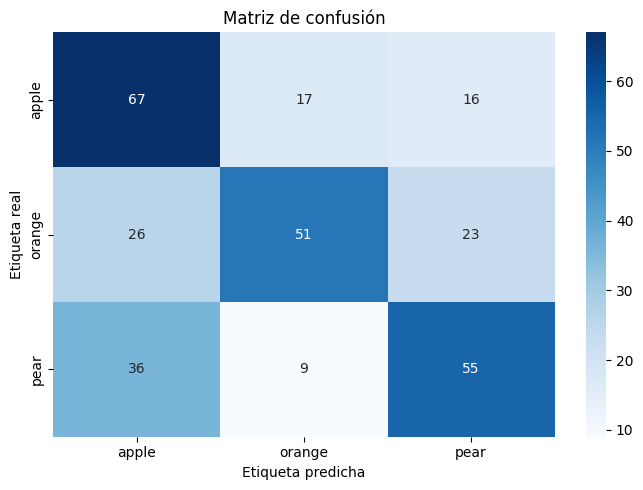

In [13]:
matriz = confusion_matrix(y_real, y_pred)

print("Matriz de confusión:")
print(matriz)

plt.figure(figsize=(7, 5))
sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clases_seleccionadas,
    yticklabels=clases_seleccionadas
)

plt.title("Matriz de confusión")
plt.xlabel("Etiqueta predicha")
plt.ylabel("Etiqueta real")
plt.tight_layout()
plt.show()


## 14. Reporte de clasificación

In [14]:
print(classification_report(
    y_real,
    y_pred,
    target_names=clases_seleccionadas
))


              precision    recall  f1-score   support

       apple       0.52      0.67      0.59       100
      orange       0.66      0.51      0.58       100
        pear       0.59      0.55      0.57       100

    accuracy                           0.58       300
   macro avg       0.59      0.58      0.58       300
weighted avg       0.59      0.58      0.58       300



## 15. Ejemplos reales vs predichos

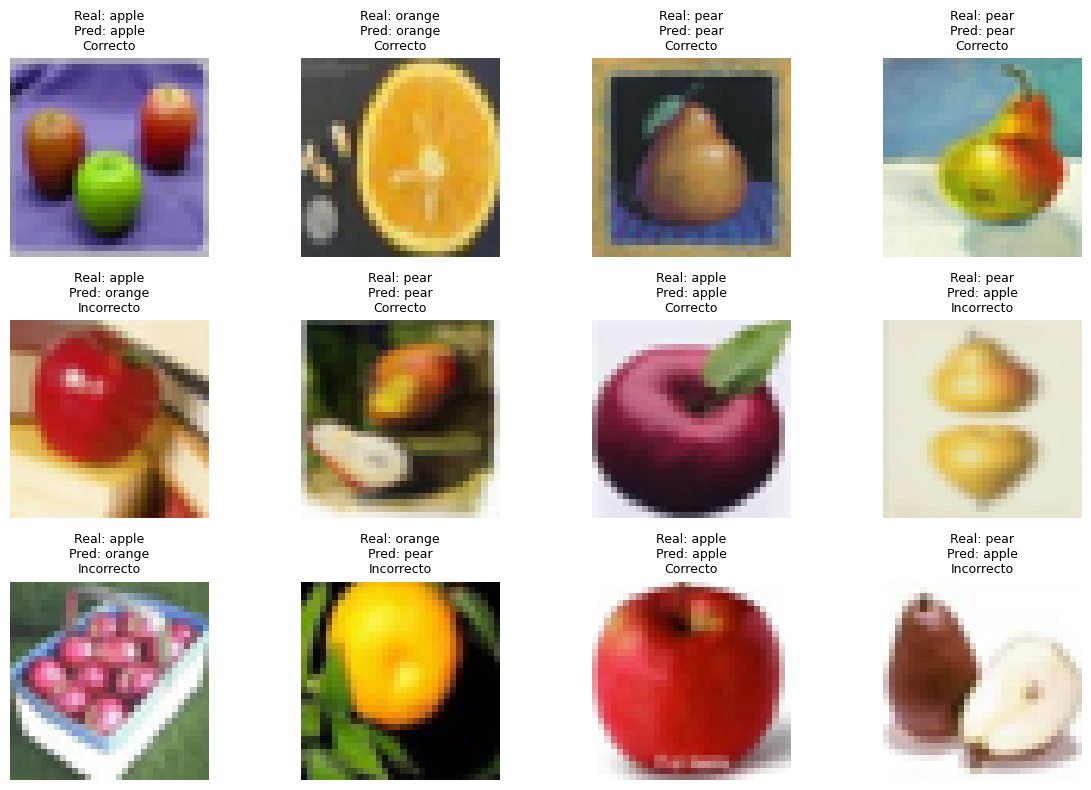

In [15]:
def mostrar_predicciones(x_original, y_real, y_pred, clases, cantidad=12):
    plt.figure(figsize=(12, 8))

    for i in range(cantidad):
        imagen = convertir_a_imagen(x_original[i])
        plt.subplot(3, 4, i + 1)
        plt.imshow(imagen)

        real = clases[y_real[i]]
        predicho = clases[y_pred[i]]
        estado = "Correcto" if real == predicho else "Incorrecto"

        plt.title(f"Real: {real}\nPred: {predicho}\n{estado}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


mostrar_predicciones(
    x_test_filtrado,
    y_real,
    y_pred,
    clases_seleccionadas,
    cantidad=12
)


## 16. Ejemplos de errores

Cantidad de errores encontrados: 127


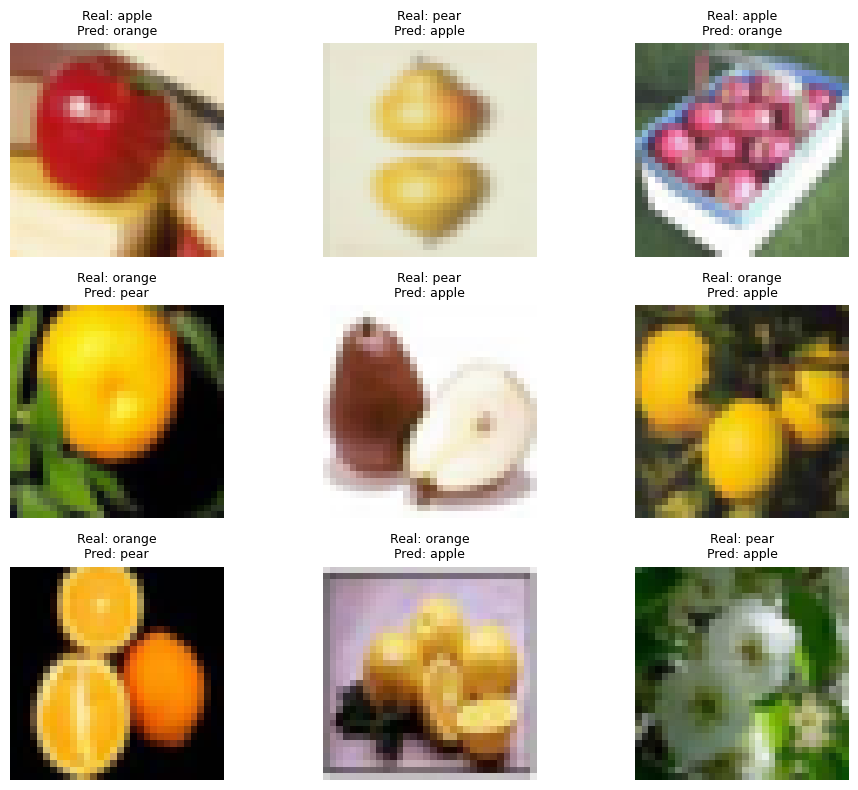

In [16]:
def mostrar_errores(x_original, y_real, y_pred, clases, cantidad=9):
    indices_errores = np.where(y_real != y_pred)[0]
    print("Cantidad de errores encontrados:", len(indices_errores))

    if len(indices_errores) == 0:
        print("No hubo errores de clasificación.")
        return

    cantidad = min(cantidad, len(indices_errores))
    plt.figure(figsize=(10, 8))

    for i, indice in enumerate(indices_errores[:cantidad]):
        imagen = convertir_a_imagen(x_original[indice])
        plt.subplot(3, 3, i + 1)
        plt.imshow(imagen)

        real = clases[y_real[indice]]
        predicho = clases[y_pred[indice]]

        plt.title(f"Real: {real}\nPred: {predicho}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


mostrar_errores(
    x_test_filtrado,
    y_real,
    y_pred,
    clases_seleccionadas,
    cantidad=9
)
